In [1]:
import os
import cv2
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import MinMaxScaler
import tarfile
from sklearn.decomposition import PCA

In [2]:
import tarfile

file_path = "/content/pill.tar.xz"
with tarfile.open(file_path, "r:xz") as tar:
    tar.extractall(path="/content/", filter="data")

In [3]:
!ls /content
!ls /content/pill
!ls /content/pill/train
!ls /content/pill/test

pill  pill.tar.xz  sample_data
ground_truth  license.txt  readme.txt  test  train
good
color  combined  contamination	crack  faulty_imprint  good  pill_type	scratch


In [4]:
## loading Normal Images
train_path = "/content/pill/train/good"
def load_images(folder, size=(128,128)):
    X = []
    for file in os.listdir(folder):
        if file.lower().endswith((".png",".jpg",".jpeg")):
            path = os.path.join(folder,file)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, size)
            img = img / 255.0
            X.append(img.flatten())
    return np.array(X)
X_train = load_images(train_path)
print(X_train.shape)

(267, 16384)


In [5]:
import os
print(os.listdir("/content/pill"))

['ground_truth', 'license.txt', 'test', 'readme.txt', 'train']


In [6]:
test_path = "/content/pill/test"
train_path = "/content/pill/train/good"

X_test = []
y_test = []

for folder in os.listdir(test_path):

    folder_path = os.path.join(test_path, folder)

    if os.path.isdir(folder_path):

        label = 0 if folder == "good" else 1

        for file in os.listdir(folder_path):
            if file.lower().endswith((".png",".jpg",".jpeg")):

                path = os.path.join(folder_path,file)

                img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
                img = cv2.resize(img, (128,128))
                img = img / 255.0

                X_test.append(img.flatten())
                y_test.append(label)

X_test = np.array(X_test)
y_test = np.array(y_test)

print(X_test.shape)
print(y_test.shape)

(167, 16384)
(167,)


In [25]:
## data scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


iso = IsolationForest(n_estimators=300,contamination="auto",random_state=42)
iso.fit(X_train_s)
scores_iso = -iso.decision_function(X_test_s)
auc_iso = roc_auc_score(y_test, scores_iso)

print("Isolation Forest ROC-AUC:",round(auc_iso, 4))

# threshold for isolation forest
th_iso = np.percentile(scores_iso,30)
pred_iso = (scores_iso > th_iso).astype(int)


print("\nIsolation Forest Classification Report:")
print(classification_report(y_test, pred_iso, digits=4))

Isolation Forest ROC-AUC: 0.7046

Isolation Forest Classification Report:
              precision    recall  f1-score   support

           0     0.2400    0.4615    0.3158        26
           1     0.8803    0.7305    0.7984       141

    accuracy                         0.6886       167
   macro avg     0.5602    0.5960    0.5571       167
weighted avg     0.7806    0.6886    0.7233       167



In [24]:

svm = OneClassSVM(kernel="rbf",gamma="scale",nu=0.05)
svm.fit(X_train_s)
scores_svm = -svm.decision_function(X_test_s)
auc_svm = roc_auc_score(y_test, scores_svm)


print("One-Class SVM ROC-AUC:", round(auc_svm, 4))

# Threshold for SVM
th_svm = np.percentile(scores_svm, 30)
pred_svm = (scores_svm > th_svm).astype(int)



print("\nOne-Class SVM Classification Report:")
print(classification_report(y_test, pred_svm, digits=4))

One-Class SVM ROC-AUC: 0.8328

One-Class SVM Classification Report:
              precision    recall  f1-score   support

           0     0.3800    0.7308    0.5000        26
           1     0.9402    0.7801    0.8527       141

    accuracy                         0.7725       167
   macro avg     0.6601    0.7555    0.6764       167
weighted avg     0.8530    0.7725    0.7978       167



In [23]:
## LOF

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
lof = LocalOutlierFactor(n_neighbors=5,novelty=True)
lof.fit(X_train_s)

LOF_scores = -lof.decision_function(X_test_s)
auc = roc_auc_score(y_test, LOF_scores)
print("LOF ROC-AUC:", round(auc, 4))

threshold = np.percentile(LOF_scores,30)
pred = (LOF_scores > threshold).astype(int)
cm = confusion_matrix(y_test, pred)


print("\nClassification Report:")
print(classification_report(y_test, pred, digits=4))

LOF ROC-AUC: 0.8781

Classification Report:
              precision    recall  f1-score   support

           0     0.4200    0.8077    0.5526        26
           1     0.9573    0.7943    0.8682       141

    accuracy                         0.7964       167
   macro avg     0.6886    0.8010    0.7104       167
weighted avg     0.8736    0.7964    0.8191       167



In [22]:
## PCA
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

pca = PCA(n_components=0.85,random_state=42)
pca.fit(X_train_s)

X_proj = pca.transform(X_test_s)
X_recon = pca.inverse_transform(X_proj)


PCA_scores = np.mean((X_test_s - X_recon) ** 2, axis=1)

auc = roc_auc_score(y_test, PCA_scores)
print("PCA ROC-AUC:", round(auc,4))

threshold = np.percentile(PCA_scores, 20)
pred = (PCA_scores > threshold).astype(int)



print("\nClassification Report:")
print(classification_report(y_test, pred, digits=4))


PCA ROC-AUC: 0.8554

Classification Report:
              precision    recall  f1-score   support

           0     0.5000    0.6538    0.5667        26
           1     0.9323    0.8794    0.9051       141

    accuracy                         0.8443       167
   macro avg     0.7162    0.7666    0.7359       167
weighted avg     0.8650    0.8443    0.8524       167



In [21]:
## ensemble model Isolation Forest + SVM
mm = MinMaxScaler()
iso_norm = mm.fit_transform(scores_iso.reshape(-1,1)).ravel()
svm_norm = mm.fit_transform(scores_svm.reshape(-1,1)).ravel()

combined_SVM_ISO = 0.5*iso_norm + 0.5*svm_norm

print("SVM + Isolation Forest Ensemble ROC-AUC:",
      roc_auc_score(y_test,combined_SVM_ISO))

threshold = np.percentile(combined_SVM_ISO, 40)
pred = (combined_SVM_ISO > threshold).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, pred, digits=4))

SVM + Isolation Forest Ensemble ROC-AUC: 0.8297872340425533

Classification Report:
              precision    recall  f1-score   support

           0     0.3134    0.8077    0.4516        26
           1     0.9500    0.6738    0.7884       141

    accuracy                         0.6946       167
   macro avg     0.6317    0.7407    0.6200       167
weighted avg     0.8509    0.6946    0.7360       167



In [28]:

pca_norm = MinMaxScaler().fit_transform(PCA_scores.reshape(-1, 1)).ravel()
lof_norm = MinMaxScaler().fit_transform(LOF_scores.reshape(-1, 1)).ravel()


combined_scores = 0.9 * lof_norm + 0.1 * pca_norm


auc = roc_auc_score(y_test, combined_scores)
print("ROC-AUC:", round(auc, 4))

threshold = np.percentile(combined_scores, 10)
pred = (combined_scores > threshold).astype(int)


print("\nClassification Report:")
print(classification_report(y_test, pred, digits=4))

ROC-AUC: 0.8783

Classification Report:
              precision    recall  f1-score   support

           0     0.6471    0.4231    0.5116        26
           1     0.9000    0.9574    0.9278       141

    accuracy                         0.8743       167
   macro avg     0.7735    0.6903    0.7197       167
weighted avg     0.8606    0.8743    0.8630       167



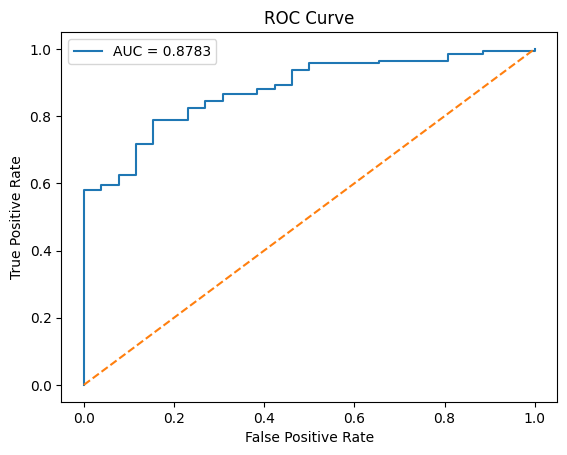

In [13]:
## AUC-ROC
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr,tpr, _ = roc_curve(y_test, combined_scores)

plt.plot(fpr, tpr, label="AUC = 0.8783")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

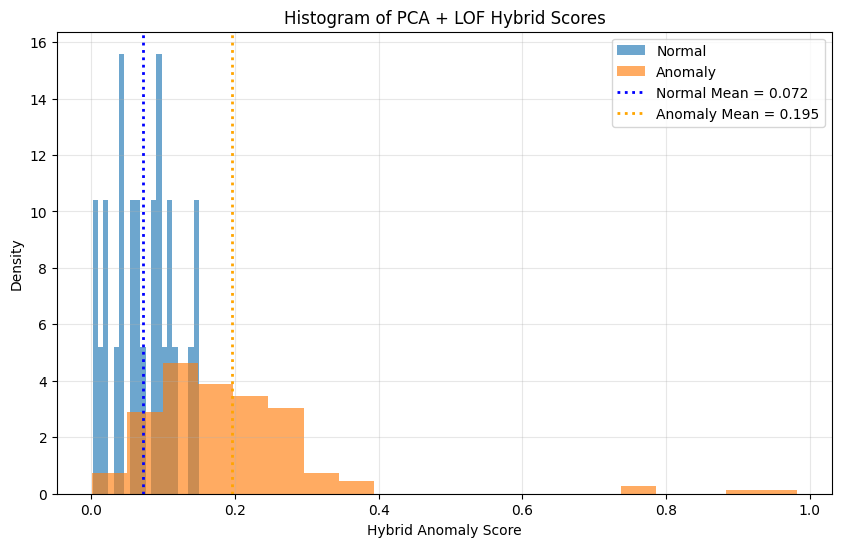

Mean Normal Score: 0.0716
Mean Anomaly Score: 0.1953
Mean Score Separation: 0.1236


In [27]:

normal_scores = combined_scores[y_test == 0]
anomaly_scores = combined_scores[y_test == 1]


mean_normal = np.mean(normal_scores)
mean_anomaly = np.mean(anomaly_scores)

plt.figure(figsize=(10, 6))
plt.hist(normal_scores,bins=20,alpha=0.65,label="Normal",density=True)


plt.hist(anomaly_scores,bins=20,alpha=0.65,label="Anomaly",density=True)

plt.axvline(mean_normal,linestyle=":",linewidth=2,color="blue",label=f"Normal Mean = {mean_normal:.3f}")

plt.axvline(mean_anomaly,linestyle=":",linewidth=2,color="orange",label=f"Anomaly Mean = {mean_anomaly:.3f}")


plt.xlabel("Hybrid Anomaly Score")
plt.ylabel("Density")
plt.title("Histogram of PCA + LOF Hybrid Scores")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Mean Normal Score:", round(mean_normal, 4))
print("Mean Anomaly Score:", round(mean_anomaly, 4))
print("Mean Score Separation:", round(mean_anomaly - mean_normal, 4))

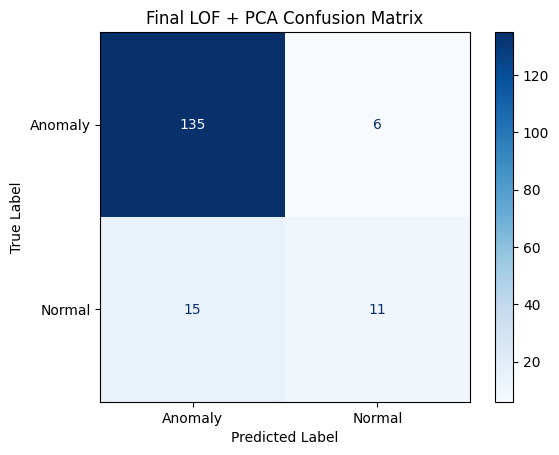

In [30]:
cm = confusion_matrix(y_test, pred, labels=[1,0])

disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Anomaly", "Normal"])

disp.plot(cmap="Blues", values_format="d")
plt.title("Final LOF + PCA Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()